# Урок 15.2. Скорость изменения: от средней к мгновенной

**Интерактивная версия:** `lessons/lesson_15_2/web/index.html`

**После урока вы сможете:** вычислять изменение (абсолютное и относительное) и конечные разности,
находить среднюю скорость $\Delta f/\Delta x$ и видеть в ней наклон секущей, находить мгновенную
скорость сжатием интервала, понимать, когда её нет и почему маленькое $h$ опасно на компьютере,
строить скорость и ускорение как функции, восстанавливать путь по скорости и считать скорость
изменения потерь — по прогнозу и по числу деревьев бустинга.

Блоки урока:

1. **Изменение:** Δ, абсолютное и относительное, разности по таблице и их сумма.
2. **Средняя скорость:** единицы, наклон секущей, прямая ⇔ постоянная скорость, «туда и обратно», теорема о среднем.
3. **Мгновенная скорость:** сжатие интервала (справа, слева, по центру), восемь примеров, излом и скачок, ошибка округления.
4. **Скорость как функция:** $v(t)$, ускорение, путь по скорости.
5. **ML:** скорость изменения потерь по прогнозу и по числу деревьев.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation

from gbcourse import GradientBoosting, datasets
from gbcourse.plotting import use_course_style
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE

use_course_style()
plt.rcParams["animation.embed_limit"] = 30

s = lambda t: 3 * t**2 - t**3 / 5   # noqa: E731  путь, м
v = lambda t: 6 * t - 0.6 * t**2    # noqa: E731  спидометр, м/с
a = lambda t: 6 - 1.2 * t           # noqa: E731  ускорение, м/с²
tt = np.linspace(0, 10, 201)

## Блок 1. Изменение

### 1.1. Поездка и «призрак»

Машина проезжает 100 м за 10 с с разгоном и торможением; «призрак» всё время едет 10 м/с.
Засечки каждую секунду: чем дальше друг от друга, тем быстрее ехала машина.

t =  0 с: s =    0.0 м, призрак   0.0 м, спидометр   0.0 м/с
t =  1 с: s =    2.8 м, призрак  10.0 м, спидометр   5.4 м/с
t =  2 с: s =   10.4 м, призрак  20.0 м, спидометр   9.6 м/с
t =  3 с: s =   21.6 м, призрак  30.0 м, спидометр  12.6 м/с
t =  4 с: s =   35.2 м, призрак  40.0 м, спидометр  14.4 м/с
t =  5 с: s =   50.0 м, призрак  50.0 м, спидометр  15.0 м/с
t =  6 с: s =   64.8 м, призрак  60.0 м, спидометр  14.4 м/с
t =  7 с: s =   78.4 м, призрак  70.0 м, спидометр  12.6 м/с
t =  8 с: s =   89.6 м, призрак  80.0 м, спидометр   9.6 м/с
t =  9 с: s =   97.2 м, призрак  90.0 м, спидометр   5.4 м/с
t = 10 с: s =  100.0 м, призрак 100.0 м, спидометр   0.0 м/с


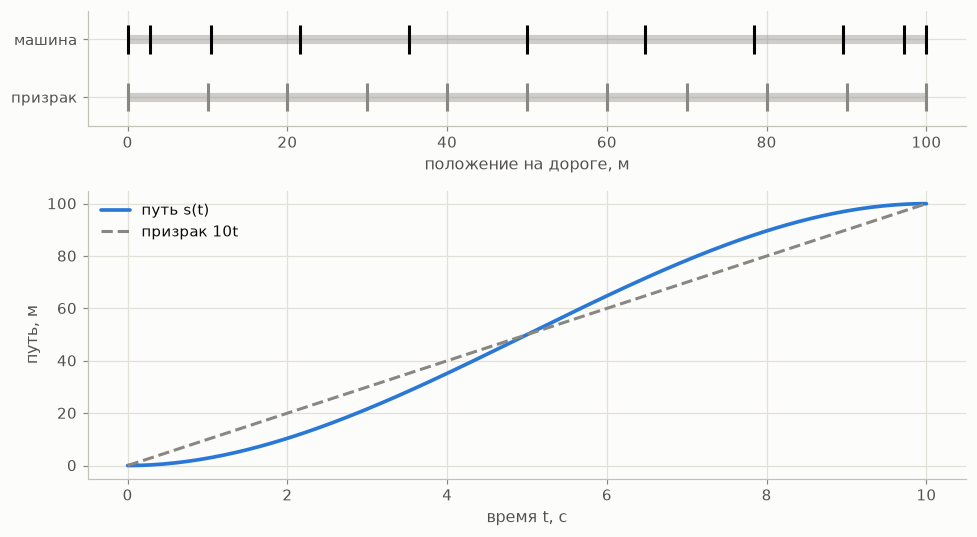

In [2]:
for t in range(11):
    print(f"t = {t:2d} с: s = {s(t):6.1f} м, призрак {10 * t:5.1f} м, спидометр {v(t):5.1f} м/с")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 5), gridspec_kw={"height_ratios": [1.2, 3]})
a1.hlines([0.6, -0.6], 0, 100, color=MUTED, lw=6, alpha=0.4)
a1.vlines([s(k) for k in range(11)], 0.3, 0.9, color="black")
a1.vlines([10 * k for k in range(11)], -0.9, -0.3, color=MUTED)
a1.set(yticks=[0.6, -0.6], yticklabels=["машина", "призрак"], xlabel="положение на дороге, м", ylim=(-1.2, 1.2))
a2.plot(tt, s(tt), color=BLUE, lw=2.4, label="путь s(t)")
a2.plot(tt, 10 * tt, "--", color=MUTED, label="призрак 10t")
a2.set(xlabel="время t, с", ylabel="путь, м")
a2.legend()
plt.tight_layout()
plt.show()

### 1.2. Абсолютное и относительное изменение

$\Delta f = f(b) - f(a)$; относительное — $\Delta f / f(a)$. Проценты перемножаются, логарифм отношения складывается.

In [3]:
for before, after in [(200, 250), (1000, 1050), (250, 200)]:
    print(f"{before} → {after}: Δ = {after - before:+d} ₽, относительно {100 * (after - before) / before:+.1f}%, "
          f"ln отношения {np.log(after / before):+.4f}")
print("+10%, затем −10%:", round(100 * 1.1 * 0.9, 2), "— итог", round(100 * (1.1 * 0.9 - 1), 2), "%")
print("точность 90% → 95%: +5 п.п., относительно", round(100 * 5 / 90, 2), "%")

200 → 250: Δ = +50 ₽, относительно +25.0%, ln отношения +0.2231
1000 → 1050: Δ = +50 ₽, относительно +5.0%, ln отношения +0.0488
250 → 200: Δ = -50 ₽, относительно -20.0%, ln отношения -0.2231
+10%, затем −10%: 99.0 — итог -1.0 %
точность 90% → 95%: +5 п.п., относительно 5.56 %


### 1.3. Конечные разности и их телескопическая сумма

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


путь:             [  0.    2.8  10.4  21.6  35.2  50.   64.8  78.4  89.6  97.2 100. ]
разности Δs:      [ 2.8  7.6 11.2 13.6 14.8 14.8 13.6 11.2  7.6  2.8]
сумма разностей:  100.0 = s(10) − s(0)
np.cumsum(Δs) восстанавливает путь: True


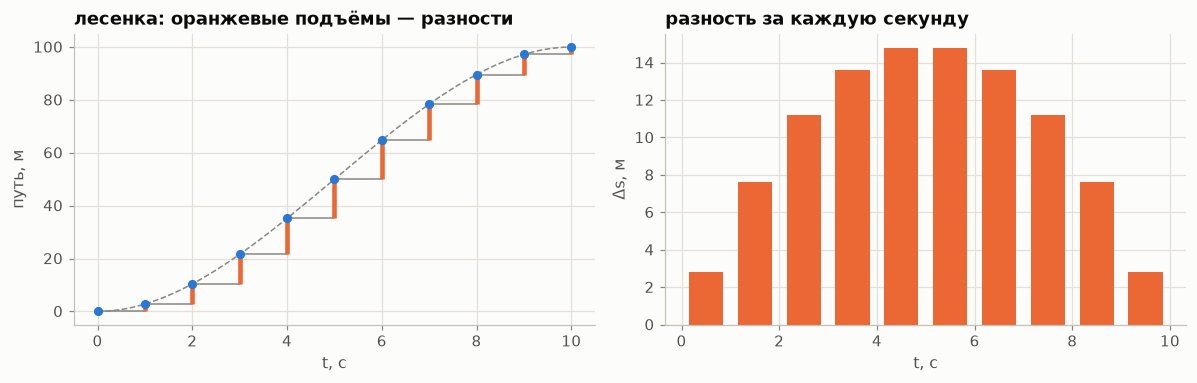

In [4]:
t = np.arange(11)
ds = np.diff(s(t))
print("путь:            ", np.round(s(t), 2))
print("разности Δs:     ", np.round(ds, 2))
print("сумма разностей: ", round(ds.sum(), 6), "= s(10) − s(0)")
print("np.cumsum(Δs) восстанавливает путь:", np.allclose(np.concatenate([[0], np.cumsum(ds)]), s(t)))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(tt, s(tt), "--", color=MUTED, lw=1)
a1.step(t, s(t), where="post", color=MUTED, lw=1)
a1.vlines(t[1:], s(t[:-1]), s(t[1:]), color=ORANGE, lw=3)
a1.plot(t, s(t), "o", color=BLUE)
a1.set(title="лесенка: оранжевые подъёмы — разности", xlabel="t, с", ylabel="путь, м")
a2.bar(t[1:] - 0.5, ds, width=0.7, color=ORANGE)
a2.set(title="разность за каждую секунду", xlabel="t, с", ylabel="Δs, м")
plt.tight_layout()
plt.show()

## Блок 2. Средняя скорость

### 2.1. Средняя скорость = наклон секущей

$\dfrac{\Delta f}{\Delta x} = \dfrac{f(b) - f(a)}{b - a}$ — изменение функции на единицу входа.

средняя за поездку: 10.0 м/с
с 2 по 4 с: 12.4 м/с
температура с 3:00 по 9:00: 1.0 °C/ч
потери с F = 1 до F = 2: -1.5


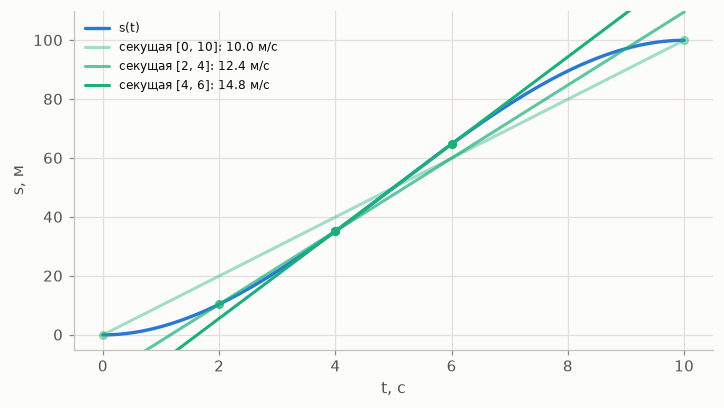

In [5]:
print("средняя за поездку:", s(10) / 10, "м/с")
print("с 2 по 4 с:", round((s(4) - s(2)) / 2, 4), "м/с")
T = lambda h: 14 - 6 * np.cos(2 * np.pi * (h - 3) / 24)  # noqa: E731
print("температура с 3:00 по 9:00:", round((T(9) - T(3)) / 6, 4), "°C/ч")
L = lambda F: 0.5 * (3 - F) ** 2  # noqa: E731
print("потери с F = 1 до F = 2:", (L(2) - L(1)) / 1)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tt, s(tt), color=BLUE, lw=2.2, label="s(t)")
for (a0, b0), alpha in [((0, 10), 0.4), ((2, 4), 0.7), ((4, 6), 1.0)]:
    k = (s(b0) - s(a0)) / (b0 - a0)
    ax.plot(tt, s(a0) + k * (tt - a0), color=AQUA, alpha=alpha, label=f"секущая [{a0}, {b0}]: {k:.1f} м/с")
    ax.plot([a0, b0], [s(a0), s(b0)], "o", color=AQUA, alpha=alpha)
ax.set(ylim=(-5, 110), xlabel="t, с", ylabel="s, м")
ax.legend(fontsize=8)
plt.show()

### 2.2. Узнаём семейство по разностям

Прямая — постоянные первые разности, парабола — вторые, кубическая — третьи, экспонента — постоянное отношение.

In [6]:
x = np.arange(7)
for name, f in [("2x + 1", 2 * x + 1), ("x²", x**2), ("2ˣ", 2.0**x), ("s(t)", s(x))]:
    print(f"{name:7} Δ = {np.round(np.diff(f), 2)}  Δ² = {np.round(np.diff(f, n=2), 2)}  Δ³ = {np.round(np.diff(f, n=3), 2)}"
          f"  отношения = {np.round(f[1:] / np.where(f[:-1] == 0, np.nan, f[:-1]), 3)}")

2x + 1  Δ = [2 2 2 2 2 2]  Δ² = [0 0 0 0 0]  Δ³ = [0 0 0 0]  отношения = [3.    1.667 1.4   1.286 1.222 1.182]
x²      Δ = [ 1  3  5  7  9 11]  Δ² = [2 2 2 2 2]  Δ³ = [0 0 0 0]  отношения = [  nan 4.    2.25  1.778 1.562 1.44 ]
2ˣ      Δ = [ 1.  2.  4.  8. 16. 32.]  Δ² = [ 1.  2.  4.  8. 16.]  Δ³ = [1. 2. 4. 8.]  отношения = [2. 2. 2. 2. 2. 2.]
s(t)    Δ = [ 2.8  7.6 11.2 13.6 14.8 14.8]  Δ² = [4.8 3.6 2.4 1.2 0. ]  Δ³ = [-1.2 -1.2 -1.2 -1.2]  отношения = [  nan 3.714 2.077 1.63  1.42  1.296]


### 2.3. Средняя скорость — не среднее скоростей

In [7]:
v1, v2, D = 60, 40, 120
time = D / v1 + D / v2
print(f"туда {D / v1} ч, обратно {D / v2} ч; средняя {2 * D / time:.1f} км/ч, а не {(v1 + v2) / 2}")
print("формула 2·v1·v2/(v1 + v2):", 2 * v1 * v2 / (v1 + v2))
sizes, means = np.array([100, 10]), np.array([0.2, 1.0])
print("среднее средних:", means.mean(), " честное среднее:", round((sizes * means).sum() / sizes.sum(), 4))

туда 2.0 ч, обратно 3.0 ч; средняя 48.0 км/ч, а не 50.0
формула 2·v1·v2/(v1 + v2): 48.0
среднее средних: 0.6  честное среднее: 0.2727


### 2.4. Теорема о среднем

Средняя скорость 10 м/с. Где спидометр показал ровно 10? Решаем $6c - 0.6c^2 = 10$.

моменты: [2.1132 7.8868]   скорость в них: [10. 10.]


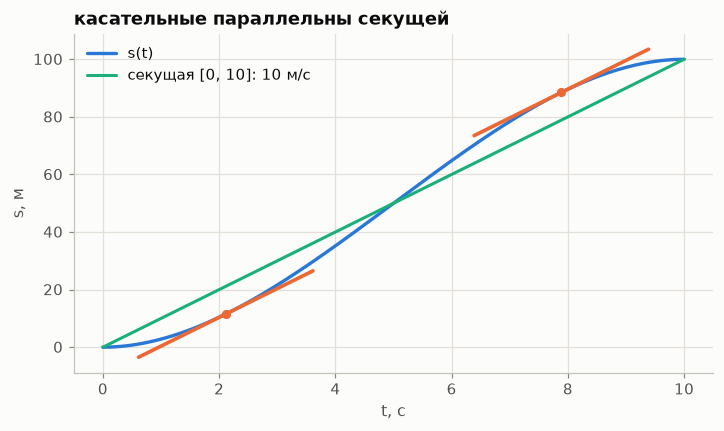

In [8]:
c = np.sort(np.roots([-0.6, 6, -10]))
print("моменты:", np.round(c, 4), "  скорость в них:", np.round(v(c), 6))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(tt, s(tt), color=BLUE, lw=2.2, label="s(t)")
ax.plot(tt, 10 * tt, color=AQUA, label="секущая [0, 10]: 10 м/с")
for ci in c:
    seg = np.linspace(ci - 1.5, ci + 1.5, 2)
    ax.plot(seg, s(ci) + 10 * (seg - ci), color=ORANGE, lw=2.4)
    ax.plot(ci, s(ci), "o", color=ORANGE)
ax.set(xlabel="t, с", ylabel="s, м", title="касательные параллельны секущей")
ax.legend()
plt.show()

## Блок 3. Мгновенная скорость

### 3.1. Сжимаем интервал: справа, слева, по центру

$\dfrac{s(2 + h) - s(2)}{h} = 9.6 + 1.8h - 0.2h^2 \to 9.6$; центральная разность $= 9.6 - 0.2h^2$.

In [9]:
print("     h      справа      слева      центр     формула 9.6 + 1.8h − 0.2h²")
for h in [1, 0.5, 0.1, 0.01, 0.001]:
    right = (s(2 + h) - s(2)) / h
    left = (s(2) - s(2 - h)) / h
    center = (s(2 + h) - s(2 - h)) / (2 * h)
    print(f"{h:7}  {right:9.6f}  {left:9.6f}  {center:9.7f}   {9.6 + 1.8 * h - 0.2 * h * h:9.6f}")
print("спидометр v(2) =", v(2))

     h      справа      слева      центр     формула 9.6 + 1.8h − 0.2h²
      1  11.200000   7.600000  9.4000000   11.200000
    0.5  10.450000   8.650000  9.5500000   10.450000
    0.1   9.778000   9.418000  9.5980000    9.778000
   0.01   9.617980   9.581980  9.5999800    9.617980
  0.001   9.601800   9.598200  9.5999998    9.601800
спидометр v(2) = 9.6


### Анимация: секущая прижимается к касательной

In [10]:
hs = 3 * 10 ** (-2.5 * np.arange(36) / 35)
t0 = 2
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6), dpi=72)
a1.plot(tt, s(tt), color=BLUE, lw=2)
a1.plot(tt, s(t0) + v(t0) * (tt - t0), "--", color=ORANGE)
sec, = a1.plot([], [], color=AQUA, lw=2)
pts, = a1.plot([], [], "o", color=AQUA)
a1.set(ylim=(-5, 110), xlabel="t", title="секущая → касательная")
avg = (s(t0 + hs) - s(t0)) / hs
a2.semilogx(hs, avg, color=AQUA, lw=2)
a2.axhline(v(t0), color=ORANGE, ls="--", label="спидометр 9.6")
cur, = a2.plot([], [], "o", color=AQUA, ms=8)
a2.invert_xaxis()
a2.set(xlabel="h", ylabel="Δs/h", title="средняя скорость → 9.6")
a2.legend()


def frame(i):
    h, k = hs[i], avg[i]
    sec.set_data(tt, s(t0) + k * (tt - t0))
    pts.set_data([t0, t0 + h], [s(t0), s(t0 + h)])
    cur.set_data([h], [k])
    return sec, pts, cur


anim = animation.FuncAnimation(fig, frame, frames=len(hs), interval=150)
plt.close(fig)
display(HTML(anim.to_jshtml()))

### 3.2. Восемь примеров: разностное отношение при маленьком $h$

Рецепт: $f(a + h) - f(a)$ → вынести $h$ → сократить → $h \to 0$. Сверим числа с ответами из урока.

In [11]:
examples = [
    ("5", lambda x: 5 + 0 * x, 1, 0),
    ("3x + 2", lambda x: 3 * x + 2, 1, 3),
    ("x² в 3", lambda x: x**2, 3, 6),
    ("x² в −1", lambda x: x**2, -1, -2),
    ("x³ в 1", lambda x: x**3, 1, 3),
    ("1/x в 2", lambda x: 1 / x, 2, -0.25),
    ("√x в 4", np.sqrt, 4, 0.25),
    ("s(t) в 5", s, 5, 15),
]
for name, f, x0, ans in examples:
    q = [(f(x0 + h) - f(x0)) / h for h in (0.1, 0.001)]
    print(f"{name:10} q(0.1) = {q[0]:9.5f}  q(0.001) = {q[1]:9.5f}  → {ans}")

5          q(0.1) =   0.00000  q(0.001) =   0.00000  → 0
3x + 2     q(0.1) =   3.00000  q(0.001) =   3.00000  → 3
x² в 3     q(0.1) =   6.10000  q(0.001) =   6.00100  → 6
x² в −1    q(0.1) =  -1.90000  q(0.001) =  -1.99900  → -2
x³ в 1     q(0.1) =   3.31000  q(0.001) =   3.00300  → 3
1/x в 2    q(0.1) =  -0.23810  q(0.001) =  -0.24988  → -0.25
√x в 4     q(0.1) =   0.24846  q(0.001) =   0.24998  → 0.25
s(t) в 5   q(0.1) =  14.99800  q(0.001) =  15.00000  → 15


### 3.3. Выколотая точка: $q(h)$ при $h = 0$ не определено

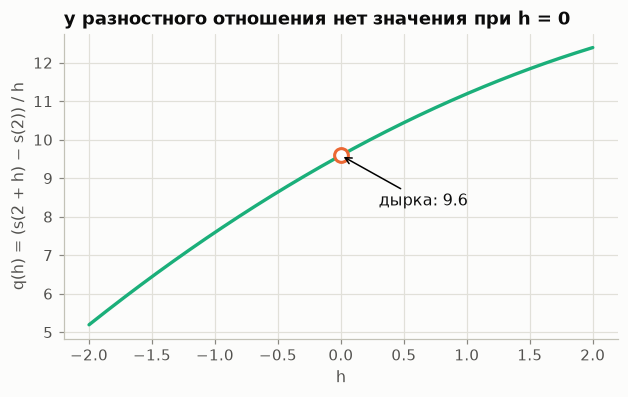

In [12]:
hh = np.linspace(-2, 2, 401)
hh = hh[np.abs(hh) > 1e-9]
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(hh, (s(2 + hh) - s(2)) / hh, color=AQUA, lw=2.2)
ax.plot(0, 9.6, "o", mfc="white", mec=ORANGE, ms=9, mew=2)
ax.annotate("дырка: 9.6", (0, 9.6), (0.3, 8.3), arrowprops=dict(arrowstyle="->"))
ax.set(xlabel="h", ylabel="q(h) = (s(2 + h) − s(2)) / h", title="у разностного отношения нет значения при h = 0")
plt.show()

### 3.4. Когда мгновенной скорости нет: излом, скачок, вертикаль

In [13]:
cases = {"x²": lambda x: x**2, "|x|": np.abs, "ступенька": lambda x: np.where(x < 0, 1.0, 3.0), "∛x": np.cbrt}
for name, f in cases.items():
    row = []
    for h in (0.1, 0.001):
        right = float((f(h) - f(0.0)) / h)
        left = float((f(0.0) - f(-h)) / h)
        row.append(f"h = {h}: справа {right:9.3f}, слева {left:9.3f}")
    print(f"{name:10}", " | ".join(row))

x²         h = 0.1: справа     0.100, слева    -0.100 | h = 0.001: справа     0.001, слева    -0.001
|x|        h = 0.1: справа     1.000, слева    -1.000 | h = 0.001: справа     1.000, слева    -1.000
ступенька  h = 0.1: справа     0.000, слева    20.000 | h = 0.001: справа     0.000, слева  2000.000
∛x         h = 0.1: справа     4.642, слева     4.642 | h = 0.001: справа   100.000, слева   100.000


### 3.5. Компьютер и маленькие $h$: ошибка метода против ошибки округления

h = 1e-1   ошибка справа   1.8e-01  по центру   2.0e-03
h = 1e-2   ошибка справа   1.8e-02  по центру   2.0e-05
h = 1e-3   ошибка справа   1.8e-03  по центру   2.0e-07
h = 1e-4   ошибка справа   1.8e-04  по центру   2.0e-09
h = 1e-5   ошибка справа   1.8e-05  по центру   9.8e-11
h = 1e-6   ошибка справа   1.8e-06  по центру   2.8e-10
h = 1e-7   ошибка справа   1.5e-07  по центру   1.4e-08
h = 1e-8   ошибка справа   9.4e-08  по центру   9.4e-08
h = 1e-9   ошибка справа   7.9e-07  по центру   7.9e-07
h = 1e-10  ошибка справа   7.9e-07  по центру   7.9e-07
h = 1e-11  ошибка справа   3.5e-05  по центру   3.5e-05
h = 1e-12  ошибка справа   1.2e-03  по центру   1.2e-03
h = 1e-13  ошибка справа   1.0e-02  по центру   1.2e-03
h = 1e-14  ошибка справа   1.7e-01  по центру   1.7e-01
h = 1e-15  ошибка справа   7.2e-01  по центру   1.1e+00
h = 1e-16  ошибка справа   9.6e+00  по центру   9.6e+00
2 + 1e-16 == 2: True


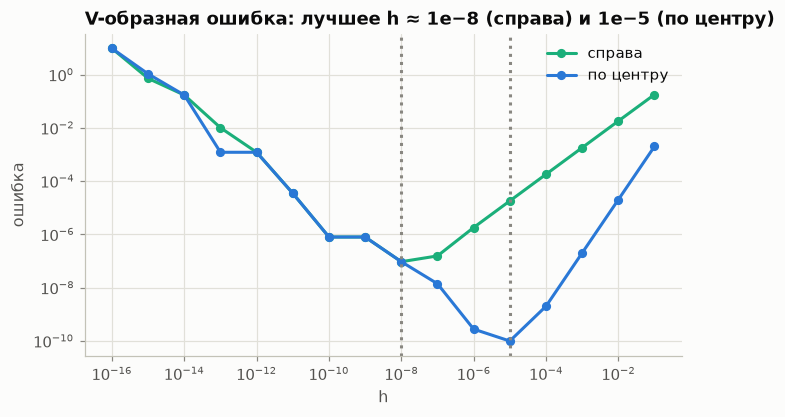

In [14]:
s_mul = lambda t: 3 * t * t - t * t * t / 5  # noqa: E731  как в JS-виджете
ks = np.arange(1, 17)
err_f, err_c = [], []
for k in ks:
    h = 10.0**-k
    err_f.append(abs((s_mul(2 + h) - s_mul(2)) / h - 9.6))
    err_c.append(abs((s_mul(2 + h) - s_mul(2 - h)) / (2 * h) - 9.6))
for k, ef, ec in zip(ks, err_f, err_c):
    print(f"h = 1e-{k:<3} ошибка справа {ef:9.1e}  по центру {ec:9.1e}")
print("2 + 1e-16 == 2:", 2 + 1e-16 == 2)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.loglog(10.0**-ks, np.maximum(err_f, 1e-17), "o-", color=AQUA, label="справа")
ax.loglog(10.0**-ks, np.maximum(err_c, 1e-17), "o-", color=BLUE, label="по центру")
ax.axvline(1e-8, color=MUTED, ls=":")
ax.axvline(1e-5, color=MUTED, ls=":")
ax.set(xlabel="h", ylabel="ошибка", title="V-образная ошибка: лучшее h ≈ 1e−8 (справа) и 1e−5 (по центру)")
ax.legend()
plt.show()

## Блок 4. Скорость как функция

### 4.1. Путь, скорость, ускорение

$v(t) = 6t - 0.6t^2$, $a(t) = 6 - 1.2t$. Численно — `np.gradient` по таблице замеров.

макс. ошибка скорости внутри: 2.0e-03
ускорение в 1, 5, 9 с (численно): [ 4.8  0.  -4.8]  точно: [ 4.8  0.  -4.8]


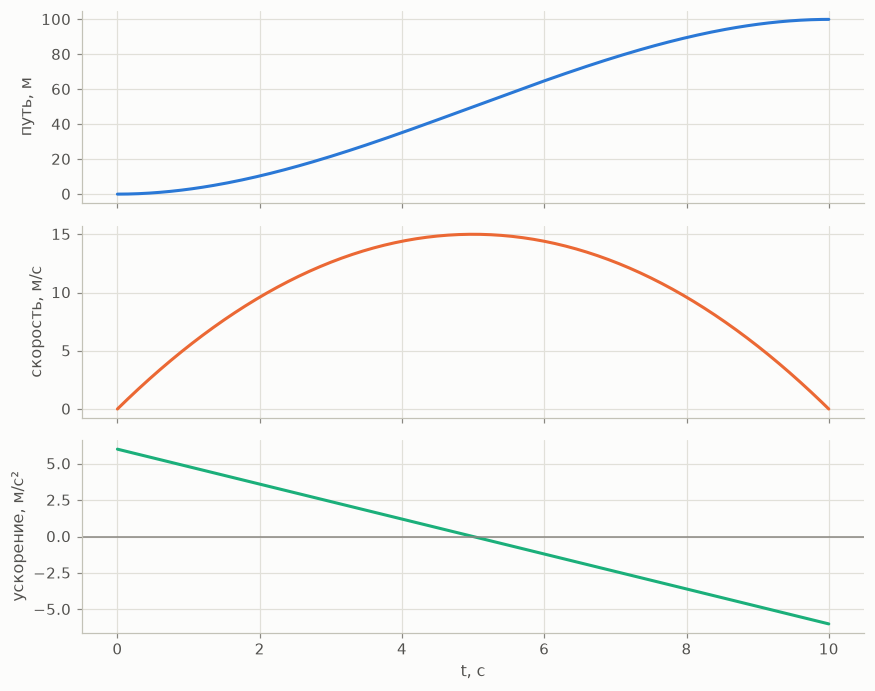

In [15]:
t10 = np.linspace(0, 10, 101)
vel = np.gradient(s(t10), t10)
accn = np.gradient(vel, t10)
print("макс. ошибка скорости внутри:", f"{np.max(np.abs(vel - v(t10))[1:-1]):.1e}")
print("ускорение в 1, 5, 9 с (численно):", np.round(accn[[10, 50, 90]], 3), " точно:", a(np.array([1, 5, 9])))

fig, axs = plt.subplots(3, 1, figsize=(8, 6.4), sharex=True)
axs[0].plot(tt, s(tt), color=BLUE)
axs[0].set(ylabel="путь, м")
axs[1].plot(tt, v(tt), color=ORANGE)
axs[1].set(ylabel="скорость, м/с")
axs[2].plot(tt, a(tt), color=AQUA)
axs[2].axhline(0, color=MUTED, lw=1)
axs[2].set(ylabel="ускорение, м/с²", xlabel="t, с")
plt.tight_layout()
plt.show()

### 4.2. Мяч: отрицательная скорость

$y(t) = 20t - 5t^2$, $v = 20 - 10t$: вверх до 2 с, потом вниз.

In [16]:
for t in range(5):
    print(f"t = {t} с: высота {20 * t - 5 * t * t:5.1f} м, скорость {20 - 10 * t:+5.1f} м/с")

t = 0 с: высота   0.0 м, скорость +20.0 м/с
t = 1 с: высота  15.0 м, скорость +10.0 м/с
t = 2 с: высота  20.0 м, скорость  +0.0 м/с
t = 3 с: высота  15.0 м, скорость -10.0 м/с
t = 4 с: высота   0.0 м, скорость -20.0 м/с


### 4.3. Обратная задача: путь как сумма $v \cdot \Delta t$

In [17]:
for dt in [2, 1, 0.5, 0.25, 0.1]:
    k = np.arange(0, 10, dt)
    print(f"Δt = {dt:<5} скорость в начале: {np.sum(v(k) * dt):9.4f} м   в середине: {np.sum(v(k + dt / 2) * dt):9.4f} м")

Δt = 2     скорость в начале:   96.0000 м   в середине:  102.0000 м
Δt = 1     скорость в начале:   99.0000 м   в середине:  100.5000 м
Δt = 0.5   скорость в начале:   99.7500 м   в середине:  100.1250 м
Δt = 0.25  скорость в начале:   99.9375 м   в середине:  100.0312 м
Δt = 0.1   скорость в начале:   99.9900 м   в середине:  100.0050 м


## Блок 5. Скорость изменения в мире и в ML

### 5.1. Скорости вокруг нас

In [18]:
h = 1e-5
C = lambda q: 5000 + 40 * q - 0.05 * q**2 + 0.0001 * q**3  # noqa: E731
N = lambda t: 100 * 2 ** (t / 3)  # noqa: E731
B = lambda t: 100000 * 1.1**t  # noqa: E731
rate = lambda f, x: (f(x + h) - f(x - h)) / (2 * h)  # noqa: E731
print("предельные издержки при q = 100:", round(rate(C, 100), 3), "₽/шт.;  C(101) − C(100) =", round(C(101) - C(100), 3))
print("средние издержки при q = 100:", C(100) / 100, "₽/шт.")
print("бактерии: относительная скорость", [round(100 * rate(N, t) / N(t), 3) for t in (0, 3, 9)], "% в час")
print("вклад: относительная скорость", round(100 * rate(B, 5) / B(5), 3), "% в год (ln 1.1 =", round(100 * np.log(1.1), 3), ")")

предельные издержки при q = 100: 33.0 ₽/шт.;  C(101) − C(100) = 32.98
средние издержки при q = 100: 86.0 ₽/шт.
бактерии: относительная скорость [23.105, 23.105, 23.105] % в час
вклад: относительная скорость 9.531 % в год (ln 1.1 = 9.531 )


### 5.2. Скорость изменения потерь по прогнозу

$L(F) = \tfrac12(y - F)^2$: скорость $F - y$ — остаток со знаком минус. Шаг против неё — сдвиг на долю остатка.

In [19]:
y = 3
L = lambda F: 0.5 * (y - F) ** 2  # noqa: E731
for h in [0.1, 0.001, 1e-6]:
    print(f"h = {h:<6} средняя скорость в F = 1: {(L(1 + h) - L(1)) / h:.6f}")
F, nu = 1.0, 0.5
for step in range(5):
    print(f"шаг {step}: F = {F:.4f}, скорость {F - y:+.4f}, остаток {y - F:+.4f}")
    F -= nu * (F - y)

h = 0.1    средняя скорость в F = 1: -1.950000
h = 0.001  средняя скорость в F = 1: -1.999500
h = 1e-06  средняя скорость в F = 1: -1.999999
шаг 0: F = 1.0000, скорость -2.0000, остаток +2.0000
шаг 1: F = 2.0000, скорость -1.0000, остаток +1.0000
шаг 2: F = 2.5000, скорость -0.5000, остаток +0.5000
шаг 3: F = 2.7500, скорость -0.2500, остаток +0.2500
шаг 4: F = 2.8750, скорость -0.1250, остаток +0.1250


### 5.3. Скорость падения потерь по числу деревьев

ν = 0.1: Δ от деревьев 1, 10, 100: -0.0289, -0.00667, -0.000086;  лучшее M = 139 (0.0794)


ν = 0.3: Δ от деревьев 1, 10, 100: -0.0776, -0.00458, -0.000117;  лучшее M = 36 (0.0772)
ν = 1.0: Δ от деревьев 1, 10, 100: -0.1522, -0.00157, -0.000005;  лучшее M = 12 (0.0771)


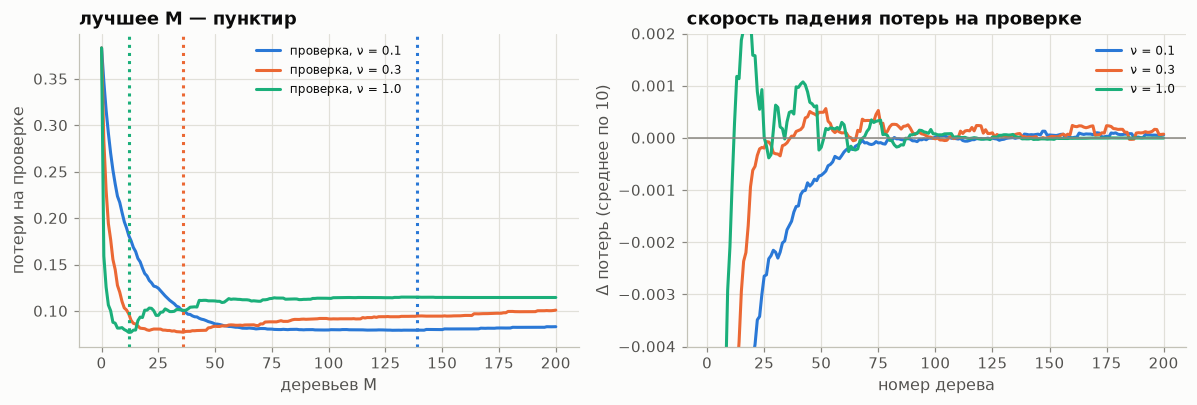

In [20]:
X, yy = datasets.regression_1d(kind="sine", n=200, noise=0.3, seed=42)
Xtr, Xva, ytr, yva = datasets.train_test_split(X, yy, test_size=0.3, seed=0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
for nu, col in [(0.1, BLUE), (0.3, ORANGE), (1.0, AQUA)]:
    m = GradientBoosting(n_estimators=200, learning_rate=nu, max_depth=2).fit(Xtr, ytr, eval_set=(Xva, yva))
    tr, va = np.array(m.history_["train"]), np.array(m.history_["eval"])
    d = np.diff(tr)
    print(f"ν = {nu}: Δ от деревьев 1, 10, 100: {d[0]:.4f}, {d[9]:.5f}, {d[99]:.6f};  лучшее M = {va.argmin()} ({va.min():.4f})")
    a1.plot(va, color=col, label=f"проверка, ν = {nu}")
    a1.axvline(va.argmin(), color=col, ls=":")
    a2.plot(np.arange(1, 201), np.convolve(np.diff(va), np.ones(10) / 10, "same"), color=col, label=f"ν = {nu}")
a1.set(xlabel="деревьев M", ylabel="потери на проверке", title="лучшее M — пунктир")
a1.legend(fontsize=8)
a2.axhline(0, color=MUTED, lw=1)
a2.set(ylim=(-0.004, 0.002), xlabel="номер дерева", ylabel="Δ потерь (среднее по 10)", title="скорость падения потерь на проверке")
a2.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Упражнения

Условия — `exercises/tasks.md`, решения — `exercises/solutions.py`.

1. ★☆☆ Цена акции: средняя и относительная скорость.
2. ★☆☆ Проценты и процентные пункты.
3. ★☆☆ Разности потерь по деревьям.
4. ★☆☆ Мгновенная скорость $x^2$ в точке 3 через $6 + h$.
5. ★★☆ Средняя скорость велосипедиста на трёх участках.
6. ★★☆ Мгновенная скорость поездки в момент 5 с.
7. ★★☆ Слева, справа и по центру в момент 2 с.
8. ★★☆ Мяч: средние и мгновенные скорости, верхняя точка.
9. ★★★ $1/x^2$ в точке 1 и $\sqrt{x}$ в точке 9.
10. ★★★ Наилучшее $h$ для численной скорости $\sin x$.
11. ★★★ Ранняя остановка по скорости падения потерь.